In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

car_data = pd.read_csv("CarPrice_Assignment.csv") #Reads the csv file

#Checks the dimension and missing values to make sure it is all set
car_data.head()
print("Dataset shape:",car_data.shape)
print("\nMissing values:")
print(car_data.isnull().sum())

Dataset shape: (205, 26)

Missing values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [2]:
y = car_data["price"] #The target variable that we want to predict

# Drop the target, ID, and full car model name as they aren't meaningful as the predictors
X = car_data.drop(
    columns=["price", "car_ID", "CarName", "enginelocation"]
)

#This splits the data into training and test data set 70/30 which returns training features, test features, training and test targets.
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.30, random_state=42)


In [3]:
categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist() #Finds all columns that are objects

numerical_columns = X.select_dtypes(
    include="number"
).columns.tolist() #Finds all columns that are numeric

#These lines display the numeric and column names to make sure that the columns are seperated correctly
print("Categorical columns:")
print(categorical_columns)
print("\nNumerical columns:")
print(numerical_columns)

preprocessor = ColumnTransformer( #
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first",handle_unknown="ignore", sparse_output=False),
            categorical_columns
        ), #This part applies the one-hot encoding to the categorical columns that can handle unseen categories alright
        ( 
            "numerical",
            "passthrough",
            numerical_columns
        ) #Leaves the numerical columns unchanged.
    ]
)


X_train_processed = preprocessor.fit_transform(X_train) # Learns the preprocessing parameters from training data and applies the transformation
X_test_processed = preprocessor.transform(X_test) #Applies the same transformation to the test data using parameters learn from training data

#Retrieves names of all features after the preprocessing
feature_names = preprocessor.get_feature_names_out()

#Gets rid of the prefixes from the feature names
clean_feature_names = [
    name.replace("categorical__", "")
        .replace("numerical__", "")
    for name in feature_names
]
#Outputs the cleaned feature names
print(clean_feature_names)

Categorical columns:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem']

Numerical columns:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
['fueltype_gas', 'aspiration_turbo', 'doornumber_two', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor', 'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_six', 'cylindernumber_twelve', 'cylindernumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl', 'fuelsystem_idi', 'fuelsystem_mpfi', 'fuelsystem_spdi', 'fuelsystem_spfi', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrp

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [4]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=clean_feature_names, #Assigns the cleaned feature names as column headers for the data frame
    index=X_train.index #Maintains the same row indices from the original training dataset
) #Converts the processed training data back into a pandas DataFrame

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=clean_feature_names,
    index=X_test.index
) # Similarly converts the processed test dataset back into pandas DataFrame with the same column names and original test set indices
X_train_processed.head()

,fueltype_gas,aspiration_turbo,doornumber_two,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,...,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
177,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,53.9,2458.0,122.0,3.31,3.54,8.7,92.0,4200.0,27.0,32.0
75,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,54.8,2910.0,140.0,3.78,3.12,8.0,175.0,5000.0,19.0,24.0
174,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,54.9,2480.0,110.0,3.27,3.35,22.5,73.0,4500.0,30.0,33.0
31,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,50.8,1819.0,92.0,2.91,3.41,9.2,76.0,6000.0,31.0,38.0
12,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,54.3,2710.0,164.0,3.31,3.19,9.0,121.0,4250.0,21.0,28.0


In [5]:
X_train_constant = sm.add_constant(
    X_train_processed
) # add our constant y = mx+b

model_results = sm.OLS(Y_train,X_train_constant).fit() # call linear regression with OLS with Y(depdendent) & X (independant + const) and build the model

print(model_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     47.94
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.07e-50
Time:                        18:10:04   Log-Likelihood:                -1275.9
No. Observations:                 143   AIC:                             2630.
Df Residuals:                     104   BIC:                             2745.
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.888e+

In [10]:
feature_significance = pd.DataFrame({
    "Feature": model_results.params.index,
    "Coefficient": model_results.params.values,
    "P_Value": model_results.pvalues.values
}) # It creates a new pandas DataFrame using the model's result of the feature variables, coefficients, and the p-values

feature_significance = feature_significance[
    feature_significance["Feature"] != "const"
] #It filters out the constant and keeps the actual feature variables

feature_significance = feature_significance.sort_values(
    by="P_Value"
).reset_index(drop=True) # Sorts the datafram in an ascending order by P-value, where the lowest P value starts at the top and the highest at the bottom
#The drop resets the dataframe index to consecutive integers starting from 0

top_3_features = feature_significance.head(3) # Select the 3 top rows where they hold the 3 most significant features (lowest p-value) and the result is assigned
#to the top_3_features variables

top_3_features

,Feature,Coefficient,P_Value
0,enginetype_ohcv,-5898.011775,0.000062
1,enginesize,121.442250,0.000127
2,stroke,-3943.183556,0.000128


In [7]:
print("Three predictors with the smallest p-values:\n") # Just prints the header

# A for loop that goes each rows where it prints out all of the rows info such as the feature with it's coefficient and p_values from
# the top_3_features variables
for index, row in top_3_features.iterrows(): 
    print(
        f"{index + 1}. {row['Feature']}\n"
        f"   Coefficient: {row['Coefficient']:.2f}\n"
        f"   P-value: {row['P_Value']:.6f}\n"
    )

Three predictors with the smallest p-values:

1. enginetype_ohcv
   Coefficient: -5898.01
   P-value: 0.000062

2. enginesize
   Coefficient: 121.44
   P-value: 0.000127

3. stroke
   Coefficient: -3943.18
   P-value: 0.000128



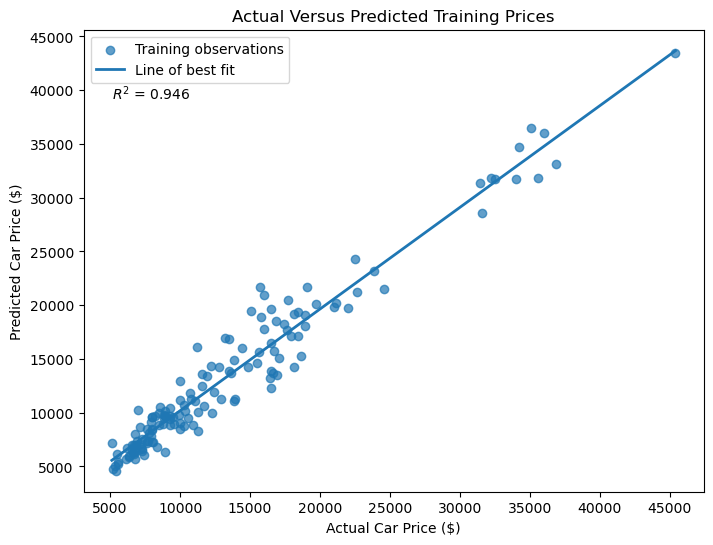

Best-fit equation: Predicted Price = 0.946(Actual Price) + 724.17


In [20]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Predicts car prices using the complete training model
train_predictions = model_results.predict(X_train_constant)

# Calculates the training R-squared by comparing actual training prices with predicted prices
train_r2 = r2_score(Y_train, train_predictions)

# Calculates the slope and intercept of the best-fit line to actual vs predicted values
slope, intercept = np.polyfit(
    Y_train,
    train_predictions,
    1
)

# Creates ordered x-values for drawing the line from minimum to maximum actual prices
fit_x = np.linspace(
    Y_train.min(),
    Y_train.max(),
    100
)

# Calculates the corresponding y-values using linear equation
fit_y = slope * fit_x + intercept

plt.figure(figsize=(8, 6))

# Plots the actual and predicted prices for training datasets with  sctual prices on x-axis and predicted prices on y-axis
plt.scatter(
    Y_train,
    train_predictions,
    alpha=0.7,
    label="Training observations" 
)

# Draws the line of best fit with a legend label
plt.plot(
    fit_x,
    fit_y,
    linewidth=2,
    label="Line of best fit"
)

#Adds labels and title
plt.xlabel("Actual Car Price ($)")
plt.ylabel("Predicted Car Price ($)")
plt.title("Actual Versus Predicted Training Prices")

#Adds the R^2 score at top left of the model
plt.text(
    Y_train.min(),
    train_predictions.max() * 0.90,
    f"$R^2$ = {train_r2:.3f}"
)

plt.legend()
plt.show()

print( #Prints the linear equation of the best-fit line
    f"Best-fit equation: "
    f"Predicted Price = {slope:.3f}(Actual Price) "
    f"+ {intercept:.2f}"
)